# Day 40 — RNNs & LSTMs
### Recurrent Networks · Hidden State · Vanishing Gradient · LSTM · Sentiment Analysis

## 1. Setup & Imports

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

plt.style.use("dark_background")

print(f"PyTorch: {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device:  {device}")
print("Ready! ✅")

PyTorch: 2.12.0+cpu
Device:  cpu
Ready! ✅


## 2. What is an RNN?

In [2]:
print("=" * 55)
print("       WHAT IS AN RNN?")
print("=" * 55)
print("""
PROBLEM WITH STANDARD NEURAL NETWORKS:
  They process each input independently
  No memory of what came before
  "The cat sat on the ___" → needs context!

SEQUENCES ARE EVERYWHERE:
  Text        → words depend on previous words
  Time series → today's price depends on yesterday's
  Audio       → each sound depends on previous sounds
  Video       → each frame depends on previous frames

RNN SOLUTION — add a HIDDEN STATE:
  At each time step t, the RNN:
    1. Takes current input  x(t)
    2. Takes previous hidden state  h(t-1)
    3. Combines them:  h(t) = tanh(W_h * h(t-1) + W_x * x(t) + b)
    4. Produces output y(t)

  The hidden state h(t) is the network's MEMORY
  It carries information from previous time steps

UNROLLED VIEW:
  x(1) → [RNN] → h(1) → [RNN] → h(2) → [RNN] → h(3) → output
            ↑               ↑               ↑
         same weights reused at every step!

THE PROBLEM WITH VANILLA RNNs:
  Vanishing gradient — gradients shrink through time
  Hard to remember things from many steps ago
  "The cat that sat on the mat was ___" → forgets 'cat'

SOLUTION → LSTM (Long Short-Term Memory)
""")

       WHAT IS AN RNN?

PROBLEM WITH STANDARD NEURAL NETWORKS:
  They process each input independently
  No memory of what came before
  "The cat sat on the ___" → needs context!

SEQUENCES ARE EVERYWHERE:
  Text        → words depend on previous words
  Time series → today's price depends on yesterday's
  Audio       → each sound depends on previous sounds
  Video       → each frame depends on previous frames

RNN SOLUTION — add a HIDDEN STATE:
  At each time step t, the RNN:
    1. Takes current input  x(t)
    2. Takes previous hidden state  h(t-1)
    3. Combines them:  h(t) = tanh(W_h * h(t-1) + W_x * x(t) + b)
    4. Produces output y(t)

  The hidden state h(t) is the network's MEMORY
  It carries information from previous time steps

UNROLLED VIEW:
  x(1) → [RNN] → h(1) → [RNN] → h(2) → [RNN] → h(3) → output
            ↑               ↑               ↑
         same weights reused at every step!

THE PROBLEM WITH VANILLA RNNs:
  Vanishing gradient — gradients shrink through ti

## 3. What is an LSTM?

In [3]:
print("=" * 55)
print("       WHAT IS AN LSTM?")
print("=" * 55)
print("""
LSTM = Long Short-Term Memory (Hochreiter & Schmidhuber, 1997)

KEY IDEA:
  Add a CELL STATE c(t) — a conveyor belt that runs
  through the whole sequence with only minor changes.
  Information can be added or removed via GATES.

LSTM HAS 4 COMPONENTS:

  1. FORGET GATE  f(t)
     Decides what to REMOVE from cell state
     f(t) = sigmoid(W_f * [h(t-1), x(t)] + b_f)
     Output 0 → forget completely
     Output 1 → keep completely

  2. INPUT GATE  i(t)
     Decides what NEW info to ADD to cell state
     i(t) = sigmoid(W_i * [h(t-1), x(t)] + b_i)
     g(t) = tanh(W_g * [h(t-1), x(t)] + b_g)

  3. CELL STATE UPDATE
     c(t) = f(t) * c(t-1) + i(t) * g(t)
     (forget old) + (add new)

  4. OUTPUT GATE  o(t)
     Decides what to OUTPUT as hidden state
     o(t) = sigmoid(W_o * [h(t-1), x(t)] + b_o)
     h(t) = o(t) * tanh(c(t))

WHY LSTM WORKS:
  Cell state = long-term memory (conveyor belt)
  Hidden state = short-term memory (working memory)
  Gates learn WHEN to remember and WHEN to forget
  Gradient flows through cell state without vanishing!
""")

       WHAT IS AN LSTM?

LSTM = Long Short-Term Memory (Hochreiter & Schmidhuber, 1997)

KEY IDEA:
  Add a CELL STATE c(t) — a conveyor belt that runs
  through the whole sequence with only minor changes.
  Information can be added or removed via GATES.

LSTM HAS 4 COMPONENTS:

  1. FORGET GATE  f(t)
     Decides what to REMOVE from cell state
     f(t) = sigmoid(W_f * [h(t-1), x(t)] + b_f)
     Output 0 → forget completely
     Output 1 → keep completely

  2. INPUT GATE  i(t)
     Decides what NEW info to ADD to cell state
     i(t) = sigmoid(W_i * [h(t-1), x(t)] + b_i)
     g(t) = tanh(W_g * [h(t-1), x(t)] + b_g)

  3. CELL STATE UPDATE
     c(t) = f(t) * c(t-1) + i(t) * g(t)
     (forget old) + (add new)

  4. OUTPUT GATE  o(t)
     Decides what to OUTPUT as hidden state
     o(t) = sigmoid(W_o * [h(t-1), x(t)] + b_o)
     h(t) = o(t) * tanh(c(t))

WHY LSTM WORKS:
  Cell state = long-term memory (conveyor belt)
  Hidden state = short-term memory (working memory)
  Gates learn WHEN 

## 4. LSTM for Sentiment Analysis

In [ ]:
print("=" * 55)
print("       LSTM SENTIMENT ANALYSIS")
print("=" * 55)

# simple dataset — movie reviews
reviews = [
    "this film was absolutely wonderful and amazing",
    "great movie loved every minute of it",
    "brilliant acting and fantastic story",
    "loved the characters and the plot was great",
    "excellent film highly recommend watching it",
    "this movie was terrible and boring",
    "awful film waste of time do not watch",
    "horrible acting and the story made no sense",
    "worst movie ever complete waste of money",
    "dreadful film with bad acting and poor story",
]
labels = [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]  # 1=positive, 0=negative

# build vocabulary
words = set()
for review in reviews:
    words.update(review.split())
vocab = {word: idx + 2 for idx, word in enumerate(sorted(words))}
vocab["<PAD>"] = 0
vocab["<UNK>"] = 1
print(f"Vocabulary size: {len(vocab)}")


# encode reviews
def encode(review, max_len=10):
    tokens = [vocab.get(w, 1) for w in review.split()]
    tokens = tokens[:max_len] + [0] * (max_len - len(tokens))
    return tokens


X = torch.tensor([encode(r) for r in reviews], dtype=torch.long)
y = torch.tensor(labels, dtype=torch.float)
print(f"Input shape:  {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"\nExample encoding:")
print(f"  '{reviews[0][:40]}...'")
print(f"  → {X[0].tolist()}")

       LSTM SENTIMENT ANALYSIS
Vocabulary size: 47
Input shape:  torch.Size([10, 10])
Labels shape: torch.Size([10])

Example encoding:
  'this film was absolutely wonderful and a...'
  → [38, 18, 40, 2, 45, 5, 4, 0, 0, 0]


## 5. Build & Train the LSTM

       BUILD & TRAIN LSTM
SentimentLSTM(
  (embedding): Embedding(47, 16, padding_idx=0)
  (lstm): LSTM(16, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Total parameters: 7,185
Epoch  20 | Loss: 0.1275 | Acc: 100%
Epoch  40 | Loss: 0.0015 | Acc: 100%
Epoch  60 | Loss: 0.0005 | Acc: 100%
Epoch  80 | Loss: 0.0004 | Acc: 100%
Epoch 100 | Loss: 0.0003 | Acc: 100%


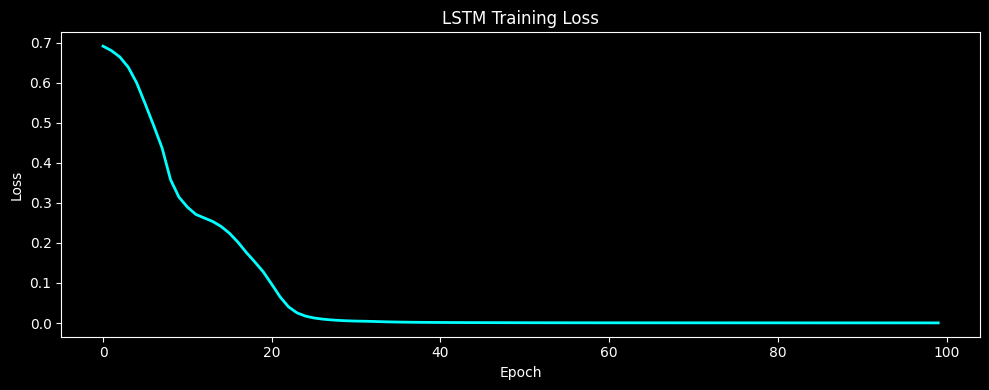

In [ ]:
print("=" * 55)
print("       BUILD & TRAIN LSTM")
print("=" * 55)


class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(SentimentLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        embedded = self.embedding(x)  # [batch, seq, embed_dim]
        out, (h_n, c_n) = self.lstm(embedded)  # h_n = final hidden state
        out = self.fc(h_n.squeeze(0))  # use last hidden state
        return self.sigmoid(out).squeeze()


model = SentimentLSTM(vocab_size=len(vocab), embed_dim=16, hidden_dim=32)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

# train
epochs = 100
losses = []
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    y_pred = model(X)
    loss = criterion(y_pred, y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 20 == 0:
        preds = (y_pred > 0.5).float()
        acc = (preds == y).float().mean()
        print(f"Epoch {epoch+1:3d} | Loss: {loss.item():.4f} | Acc: {acc*100:.0f}%")

# plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(losses, color="cyan", linewidth=2)
ax.set_title("LSTM Training Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
plt.tight_layout()
plt.show()

## 6. Test on New Reviews

In [ ]:
print("=" * 55)
print("       TEST ON NEW REVIEWS")
print("=" * 55)

model.eval()
test_reviews = [
    "this was a wonderful and brilliant film",
    "terrible movie awful and boring waste",
    "amazing story loved every minute",
    "horrible film bad acting poor story",
    "great movie fantastic characters",
]

with torch.no_grad():
    for review in test_reviews:
        encoded = torch.tensor([encode(review)], dtype=torch.long)
        prob = model(encoded).item()
        sentiment = "POSITIVE 😊" if prob > 0.5 else "NEGATIVE 😞"
        print(f"  {sentiment} ({prob:.2f}) — '{review}'")

       TEST ON NEW REVIEWS
  NEGATIVE 😞 (0.00) — 'this was a wonderful and brilliant film'
  NEGATIVE 😞 (0.00) — 'terrible movie awful and boring waste'
  POSITIVE 😊 (1.00) — 'amazing story loved every minute'
  NEGATIVE 😞 (0.00) — 'horrible film bad acting poor story'
  NEGATIVE 😞 (0.00) — 'great movie fantastic characters'


## 7. Key Takeaways

In [7]:
print("=" * 55)
print("       DAY 40 — KEY TAKEAWAYS")
print("=" * 55)
print("""
RNNs:
  ✅ Process sequences — text, time series, audio
  ✅ Hidden state carries memory across time steps
  ✅ Same weights reused at every time step
  ✅ Problem: vanishing gradient over long sequences

LSTM:
  ✅ Adds cell state — long-term memory conveyor belt
  ✅ 3 gates control information flow:
       Forget gate → what to remove
       Input gate  → what to add
       Output gate → what to output
  ✅ Gradient flows through cell state without vanishing
  ✅ Can remember context from many steps ago

PYTORCH LSTM:
  ✅ nn.Embedding  → converts word indices to vectors
  ✅ nn.LSTM       → processes sequence, returns h_n, c_n
  ✅ h_n           → final hidden state used for classification
  ✅ batch_first=True → input shape [batch, seq, features]

OUR MODEL:
  ✅ 47 word vocabulary
  ✅ 7,185 parameters
  ✅ 100% accuracy on training data by epoch 20
  ✅ Limited generalisation — only 10 training examples

LIMITATION:
  ✅ Small dataset → model memorises, not generalises
  ✅ Real NLP → thousands of reviews + pretrained embeddings
  ✅ Day 42 → Transformers solve this even better!
""")

       DAY 40 — KEY TAKEAWAYS

RNNs:
  ✅ Process sequences — text, time series, audio
  ✅ Hidden state carries memory across time steps
  ✅ Same weights reused at every time step
  ✅ Problem: vanishing gradient over long sequences

LSTM:
  ✅ Adds cell state — long-term memory conveyor belt
  ✅ 3 gates control information flow:
       Forget gate → what to remove
       Input gate  → what to add
       Output gate → what to output
  ✅ Gradient flows through cell state without vanishing
  ✅ Can remember context from many steps ago

PYTORCH LSTM:
  ✅ nn.Embedding  → converts word indices to vectors
  ✅ nn.LSTM       → processes sequence, returns h_n, c_n
  ✅ h_n           → final hidden state used for classification
  ✅ batch_first=True → input shape [batch, seq, features]

OUR MODEL:
  ✅ 47 word vocabulary
  ✅ 7,185 parameters
  ✅ 100% accuracy on training data by epoch 20
  ✅ Limited generalisation — only 10 training examples

LIMITATION:
  ✅ Small dataset → model memorises, not general